# Plano de Trabalho: Indústria Siderúrgica

## Steelproof

Etapa 1 do Projeto Final. Bootcamp de Data Science, TripleTen.


## Visão geral

O processo analisado é o refino secundário na fabricação de aço, feito em forno-panela (ladle
furnace). É uma etapa iterativa: a cada corrida, o banho metálico passa por ciclos de aquecimento
por arco elétrico, adição de ligas a granel e em arame, dessulfurização e purga com gás inerte, 
até chegar à composição química e à temperatura de entrega desejadas.

A energia de aquecimento vem de eletrodos de grafite montados na tampa da panela. É uma operação
intensiva em energia. O refino secundário consome tipicamente entre 25 e 30 kWh por tonelada de aço,
contra 350 a 600 kWh/t da fusão no forno elétrico a arco. Em volume, portanto, o forno-panela é um
consumidor secundário, mas é nele que a decisão de quanto aquecer é tomada corrida a corrida, e é
essa decisão que este projeto pretende apoiar.

Os dados cobrem 121 dias contínuos de produção, de 03/05 a 01/09/2019, com 3.214 lotes registrados.
São 26,6 corridas por dia. O enunciado do projeto informa capacidade de aproximadamente 100 toneladas
por panela, o que coloca a aciaria em torno de 2.660 toneladas diárias, ou perto de 950 mil toneladas
por ano. Nessa escala, uma economia pequena por corrida vira valor relevante no acumulado do ano.

## 1. Problema de negócio

A energia elétrica é um dos maiores custos variáveis do refino secundário. Por isso o aquecimento
precisa ser calibrado para atingir o setpoint térmico correto no vazamento gastando o mínimo
possível. O objetivo deste projeto é construir um modelo que estime a temperatura final do aço a
partir da condição inicial do banho, das adições planejadas e dos parâmetros de arco aplicados,
para servir de apoio à decisão do operador.

Hoje o processo funciona por aproximações sucessivas. O operador aquece, mede a temperatura, aplica
correção de liga, purga e mede de novo. Os dados mostram que essa sequência se repete em média cinco
vezes por corrida (4,96 medições válidas por lote). Sem uma estimativa confiável antes do
aquecimento, isso gera dois custos concretos.

O primeiro é o ciclo de ajuste desnecessário. Cada passagem extra de arco consome energia, acelera o
consumo físico do eletrodo de grafite e prolonga a permanência do lote na estação, o que reduz a
capacidade útil da aciaria sem nenhum investimento em ativo ter sido feito para compensar.

O segundo é menos óbvio e vem da incerteza. Sem previsão confiável do resfriamento causado pelas
adições de liga e pela purga, o operador trabalha com margem de segurança e tende a superaquecer o
banho para não correr o risco de entregar aço frio ao lingotamento. Os dados registram 26 corridas
(1% da amostra) terminando acima de 1.660 °C, mais de quatro desvios padrão acima da média da planta.
Esse excesso é energia gasta sem ganho de qualidade e acelera o desgaste do revestimento refratário.
Reduzir o erro da previsão reduz a margem que o operador precisa reservar.

Um modelo preciso muda a lógica da operação: em vez de buscar a temperatura certa por tentativa e
erro durante a corrida, o operador dimensiona a carga de aquecimento necessária já na entrada do
lote.

Sobre a ordem de grandeza do ganho, um cálculo preliminar ajuda a calibrar a expectativa. A 27,5
kWh/t e 950 mil toneladas por ano, o forno-panela consome cerca de 26 GWh anuais, o que a preços
industriais brasileiros de 2024 (R$ 147/MWh no mercado livre a R$ 310/MWh no cativo) representa entre
R$ 3,8 milhões e R$ 8,1 milhões por ano só de eletricidade nesta etapa. Uma redução de 5% no consumo
fica, portanto, na casa das centenas de milhares de reais por ano, mais o ganho em eletrodos e em
disponibilidade de estação. O número definitivo depende do contrato de energia da planta e será
fechado na Etapa 3, mas registro desde já que a economia esperada é dessa ordem e não de milhões,
para não prometer o que os dados não sustentam.

## 2. Descrição dos dados

### 2.1 Origem e estrutura

Os dados estão em sete arquivos CSV, cada um cobrindo uma dimensão do tratamento no forno-panela. O
vínculo entre todas as fontes é a coluna `key`, que identifica a corrida.

| Arquivo | Linhas | Colunas | Conteúdo |
|---|---:|---:|---|
| `data_arc_en.csv` | 14.876 | 5 | Janelas de aquecimento por arco, com potência ativa e reativa |
| `data_temp_en.csv` | 15.907 | 3 | Instante de amostragem e temperatura medida |
| `data_gas_en.csv` | 3.239 | 2 | Volume de gás inerte aplicado na purga |
| `data_bulk_en.csv` | 3.129 | 16 | Massa de materiais a granel adicionados, em 15 tipos |
| `data_bulk_time_en.csv` | 3.129 | 16 | Instante de cada adição a granel |
| `data_wire_en.csv` | 3.081 | 10 | Massa de ligas em arame, em 9 tipos |
| `data_wire_time_en.csv` | 3.081 | 10 | Instante de cada adição de arame |

Os arquivos de arco e de temperatura têm várias linhas por corrida, de 1 a 16 leituras, porque
registram a evolução temporal do tratamento. Os outros cinco têm exatamente uma linha por lote.

A contagem de corridas varia entre as fontes: 3.239 no gás, 3.216 na temperatura, 3.214 no arco,
3.129 no granel e 3.081 no arame. O cruzamento das tabelas vai gerar nulos onde a fonte não registrou
aquele lote, e o dataset final ficará limitado à interseção necessária. Nenhum arquivo tem linhas
duplicadas.

Antes de qualquer coisa, vale checar se o identificador acompanha o tempo. A correlação de Spearman
entre `key` e o instante do primeiro aquecimento do lote é 1,0, sem uma única inversão em 3.214
lotes. Na prática o `key` é a própria sequência cronológica de produção, o que simplifica o
ordenamento temporal. Vale registrar a contrapartida: por ser cronológico, o `key` nunca poderá
entrar como variável explicativa, sob pena de o modelo aprender a data em vez da física.

In [ ]:
import pandas as pd
import os

CANDIDATOS = ['final_steel_en', '/datasets', 'datasets', '.']
DADOS = next((d for d in CANDIDATOS if os.path.exists(f'{d}/data_arc_en.csv')), None)
if DADOS is None:
    raise FileNotFoundError(f'CSVs nao encontrados. Procurei em: {CANDIDATOS}')
print('lendo os dados de:', DADOS)

DADOS = 'final_steel_en'

arc  = pd.read_csv(f'{DADOS}/data_arc_en.csv',  parse_dates=['Arc heating start', 'Arc heating end'])
temp = pd.read_csv(f'{DADOS}/data_temp_en.csv', parse_dates=['Sampling time'])

# janela de processamento de cada lote: do primeiro aquecimento ao ultimo
janela = (arc.groupby('key')
             .agg(inicio=('Arc heating start', 'min'), fim=('Arc heating end', 'max'))
             .sort_values('inicio'))

print('periodo coberto :', janela['inicio'].min(), '->', janela['fim'].max())
print('lotes           :', len(janela))

# 1) o key acompanha a ordem do tempo?
print('key cronologico? Spearman =',
      pd.Series(janela.index).corr(
          pd.Series(janela['inicio'].values.astype('int64')), method='spearman').round(4))

# 2) existem lotes sobrepostos no tempo? (=> mais de uma estacao de tratamento)
sobrepostos = (janela['inicio'].shift(-1) < janela['fim']).sum()
print(f'lotes sobrepostos com o seguinte: {sobrepostos} de {len(janela)-1}')

# 3) intervalo entre o fim de um lote e o inicio do proximo (minutos)
gap = (janela['inicio'].shift(-1) - janela['fim']).dt.total_seconds() / 60
print('\nintervalo entre lotes consecutivos (min):')
print(gap.describe().round(1))

periodo coberto : 2019-05-03 11:02:14 -> 2019-09-01 04:36:08
lotes           : 3214
key cronologico? Spearman = 1.0
lotes sobrepostos com o seguinte: 95 de 3213

intervalo entre lotes consecutivos (min):
count    3213.0
mean       22.5
std       128.9
min      -328.1
25%         9.4
50%        14.4
75%        24.0
max      7091.6
dtype: float64


### 2.2 Ritmo de operação

Mapeando a janela de cada lote, do primeiro ao último aquecimento por arco, o tratamento dura em
média 31,6 minutos, com mediana de 27,7. O intervalo entre o fim de uma corrida e o início da
seguinte tem mediana de 14,4 minutos. Somando os dois, cada corrida ocupa a estação por cerca de 42
minutos.

A planta opera com uma única estação de tratamento ativa. Só 95 dos 3.213 intervalos se sobrepõem no
tempo ao lote seguinte, e esses 95 casos têm duração mediana de 69,6 minutos, bem acima dos 27,7
minutos do conjunto. São corridas atípicas e demoradas que invadiram o tempo da próxima panela, não
duas linhas operando em paralelo. Essa conclusão importa para a modelagem: como há uma única
estação, o tempo de descanso da panela entre corridas pode ser usado como variável explicativa sem
ambiguidade sobre a qual linha o intervalo pertence.

Houve uma única parada longa no período. O lote 1899 termina em 10/07 à 01:05 e o seguinte só entra
4,9 dias depois. Isso explica a maior parte da queda de volume em julho, que registrou 716 lotes
contra 869 em junho: a 26,6 lotes por dia, os cinco dias parados equivalem a cerca de 133 corridas
não realizadas, de uma diferença observada de 153.

In [2]:
janela['duracao'] = ((janela['fim'] - janela['inicio']).dt.total_seconds() / 60).round(1)

print('duracao do tratamento por lote (min):')
print(janela['duracao'].describe(percentiles=[.5, .9, .99]).round(1))

print('\n10 lotes mais longos:')
print(janela.nlargest(10, 'duracao'))

# os 95 sobrepostos sao causados por lotes anormalmente longos?
sobrepoe = janela['inicio'].shift(-1) < janela['fim']
print('\nduracao dos lotes que invadem o seguinte:')
print(janela.loc[sobrepoe, 'duracao'].describe())

print('\nlotes por mes (para dimensionar o corte do split):')
print(janela['inicio'].dt.to_period('M').value_counts().sort_index())

# paradas longas: candidatas a manutencao / troca de refratario
gap = ((janela['inicio'].shift(-1) - janela['fim']).dt.total_seconds() / 60).round(1)
print('\nparadas acima de 12h:')
print(janela.assign(gap_depois=gap).query('gap_depois > 720')[['inicio', 'fim', 'gap_depois']])

duracao do tratamento por lote (min):
count    3214.0
mean       31.6
std        21.1
min         1.0
50%        27.7
90%        50.1
99%       100.5
max       391.4
Name: duracao, dtype: float64

10 lotes mais longos:
                  inicio                 fim  duracao
key                                                  
1689 2019-07-02 15:25:34 2019-07-02 21:56:59    391.4
2108 2019-07-23 14:05:57 2019-07-23 19:55:39    349.7
1958 2019-07-17 21:18:46 2019-07-18 02:37:14    318.5
641  2019-05-26 20:31:15 2019-05-27 01:16:49    285.6
638  2019-05-26 19:25:11 2019-05-26 23:05:05    219.9
801  2019-06-02 01:17:12 2019-06-02 04:49:06    211.9
1881 2019-07-09 07:07:43 2019-07-09 10:38:39    210.9
46   2019-05-04 23:46:31 2019-05-05 03:08:57    202.4
1880 2019-07-09 05:54:14 2019-07-09 09:10:30    196.3
1513 2019-06-26 19:55:50 2019-06-26 23:03:03    187.2

duracao dos lotes que invadem o seguinte:
count     95.000000
mean      93.244211
std       70.244630
min       14.800000
25%       

### 2.3 Qualidade dos dados

Nas tabelas de granel e de arame, célula em branco não é dado faltante. Significa que aquele material
não foi adicionado naquela corrida. O preenchimento correto para esses vazios é zero, que é o valor
fisicamente verdadeiro, e não a média, que inventaria adições que nunca aconteceram.

As colunas `Bulk 8` e `Wire 5` têm um único registro válido cada em todo o dataset, o que dá 99,97%
de ausência, e serão descartadas por não sustentarem nenhuma inferência. No geral, 10 das 15 colunas
de granel passam de 80% de ausência, o que é esperado para materiais de uso pontual.

Em `data_arc_en.csv`, a coluna `Reactive power` tem mínimo de -715,5, contra mediana de 0,416 e
máximo de 2,676. É uma falha isolada de leitura do sensor e será tratada como valor inválido.

Em relação aos tipos de variáveis dos datasets, apenas uma correção a ser feita: as datas vêm como
textos e precisam de conversão para poderem ser corretamente utilizadas.

A duração do tratamento tem cauda longa. A mediana é 27,7 minutos, o percentil 99 chega a 100,6 e o
máximo a 391,4 minutos, quase seis horas e meia. Corridas acima de 100 minutos não representam o
processo normal, porque o aço troca calor com o refratário por tempo excessivo e a dinâmica térmica
deixa de ser a mesma. No outro extremo, tratamentos abaixo de 1 minuto indicam operação abortada. As
duas pontas serão removidas, mantendo apenas os lotes em regime operacional normal.

### 2.4 Definição da variável-alvo

A variável-alvo é a última temperatura medida de cada lote, em graus Celsius.

Como preditores entram a primeira temperatura medida do lote e as variáveis de processo aplicadas ao
longo do refino: energia de arco, volume de gás, massas de granel e arame, contagem de ciclos e
tempos. A escolha reflete o uso pretendido do modelo, que é o de simulador. Ele responde à pergunta
"se eu aplicar esta carga de energia e estas adições neste banho, com qual temperatura o aço vai
terminar?".

Sobre vazamento de dados, o cuidado central deste caso é um só e vale enunciá-lo com clareza. Nenhuma
temperatura intermediária pode entrar como preditor, apenas a primeira medição do lote. Incluir a
penúltima leitura, ou a média das leituras, produziria erro artificialmente baixo e um modelo inútil
na prática, porque exigiria como entrada uma informação que só existe depois de já gasta a energia
que se pretendia economizar.

Há ainda 739 lotes cuja última leitura de temperatura está vazia. Para preservar amostra, o alvo é
definido como a última temperatura efetivamente registrada do lote, e não a última linha do arquivo,
desde que o lote tenha ao menos duas medições válidas: uma para entrada e outra para alvo. A extração
é feita ordenando por `Sampling time`, nunca pela ordem em que as linhas aparecem no arquivo.

Entre os preditores, a expectativa é que a temperatura inicial e a energia total de arco dominem,
porque entram diretamente no balanço térmico do banho. Massas de liga e volume de gás devem
aparecer com sinal negativo, como termos de resfriamento. O intervalo desde o lote anterior é o
mais incerto dos candidatos, por ser proxy indireto do estado térmico do refratário. A verificação
dessa hipótese fica para a Etapa 2, por importância de permutação.

In [3]:
# so medicoes validas, ordenadas por lote e por instante (NAO pela ordem do arquivo)
temp_ok = temp.dropna(subset=['Temperature']).sort_values(['key', 'Sampling time'])

g = temp_ok.groupby('key')['Temperature']
base = pd.concat([
    g.first().rename('temp_inicial'),   # feature
    g.last().rename('temp_final'),      # ALVO
    g.size().rename('n_medicoes'),
], axis=1)

base = base[base['n_medicoes'] >= 2]    # precisa de 2 medicoes distintas: 1 feature + 1 alvo
print('lotes utilizaveis:', len(base))

print('\nALVO — temperatura final (C):')
print(base['temp_final'].describe(percentiles=[.01, .5, .99]).round(1))

print('\ntemperatura inicial (C):')
print(base['temp_inicial'].describe(percentiles=[.01, .5, .99]).round(1))

print('\ndelta aquecimento (final - inicial):')
print((base['temp_final'] - base['temp_inicial']).describe().round(1))

# deriva do processo + dimensionamento real do split
base = base.join(janela[['inicio', 'duracao']])
base['mes'] = base['inicio'].dt.to_period('M')
print('\nderiva por mes:')
print(base.groupby('mes')[['temp_inicial', 'temp_final']].agg(['mean', 'std', 'count']).round(1))

lotes utilizaveis: 2475

ALVO — temperatura final (C):
count    2475.0
mean     1595.3
std        16.0
min      1541.0
1%       1570.0
50%      1593.0
99%      1661.3
max      1700.0
Name: temp_final, dtype: float64

temperatura inicial (C):
count    2475.0
mean     1588.4
std        29.2
min      1191.0
1%       1532.0
50%      1588.0
99%      1651.3
max      1679.0
Name: temp_inicial, dtype: float64

delta aquecimento (final - inicial):
count    2475.0
mean        6.9
std        27.5
min       -98.0
25%        -8.0
50%         7.0
75%        22.0
max       408.0
dtype: float64

deriva por mes:
        temp_inicial             temp_final            
                mean   std count       mean   std count
mes                                                    
2019-05       1590.0  23.5   754     1596.8  16.6   754
2019-06       1586.5  32.8   869     1595.2  15.6   869
2019-07       1588.6  29.8   716     1594.2  14.9   716
2019-08       1590.7  30.2   136     1594.2  20.1   136


### 2.5 A quebra de registro em agosto

Exigindo ao menos duas medições válidas de temperatura por lote, sobram 2.475 corridas aproveitáveis
de um total de 3.216. A perda não está distribuída pelo período, e é aí que aparece o problema:

- Maio: 754 lotes utilizáveis, 100% de aproveitamento
- Junho: 869 lotes utilizáveis, 100% de aproveitamento
- Julho: 716 lotes utilizáveis, 100% de aproveitamento
- Agosto: 136 lotes utilizáveis, 15,6% de aproveitamento

Três meses inteiros sem uma única falha, seguidos de um colapso. Isso não parece degradação gradual
de sensor, que produziria perda crescente. A célula abaixo investiga o volume de registros por mês e
depois desce ao nível diário para localizar a transição.

In [4]:
# por que agosto quebrou? nulos por mes na fonte de temperatura
temp_mes = temp.join(janela['inicio'], on='key')
temp_mes['mes'] = temp_mes['inicio'].dt.to_period('M')

print('medicoes de temperatura por mes (total vs validas):')
print(temp_mes.groupby('mes')['Temperature'].agg(
    registros='size', validas='count').assign(
    pct_nulo=lambda d: (100*(1-d['validas']/d['registros'])).round(1)))

# a quebra e gradual ou tem data exata?
diario = (temp_mes[temp_mes['mes'] >= '2019-07']
          .assign(dia=lambda d: d['inicio'].dt.date)
          .groupby('dia')['Temperature'].agg(registros='size', validas='count'))
print('\nultimos dias com medicao valida:')
print(diario.tail(45))

medicoes de temperatura por mes (total vs validas):
         registros  validas  pct_nulo
mes                                  
2019-05       3859     3859       0.0
2019-06       4187     4187       0.0
2019-07       3543     3543       0.0
2019-08       4295     1412      67.1
2019-09         21        3      85.7

ultimos dias com medicao valida:
            registros  validas
dia                           
2019-07-19        117      117
2019-07-20        152      152
2019-07-21        139      139
2019-07-22        147      147
2019-07-23        125      125
2019-07-24        150      150
2019-07-25        160      160
2019-07-26        141      141
2019-07-27        126      126
2019-07-28        149      149
2019-07-29        120      120
2019-07-30        130      130
2019-07-31        156      156
2019-08-01         97       97
2019-08-02        151      151
2019-08-03        153      153
2019-08-04        127      127
2019-08-05        128      128
2019-08-06        162       

### 2.6 Diagnóstico da quebra e janela útil

A quebra tem data exata. Até 05/08/2019, 100% dos lotes têm medições completas. A partir de
06/08/2019 o sistema passa a gravar uma única medição por corrida, e a média cai de cerca de cinco
para 1,02 leituras válidas por lote.

O volume bruto de registros não cai junto, permanecendo entre 120 e 175 linhas por dia. Isso descarta
falha de sensor, porque os registros continuam existindo, e aponta para mudança no protocolo de
registro do sistema da fábrica: passou-se a guardar uma temperatura por corrida em vez de todas as
medições do ciclo.

A consequência é direta. Com uma leitura por corrida é impossível separar entrada e alvo, e o período
de 06/08 em diante fica incompatível com a formulação do problema. O descarte não introduz viés de
seleção, porque não estou removendo lotes por alguma característica deles, e sim truncando a série em
um ponto onde o instrumento mudou.

A amostra útil final é de 2.475 lotes contínuos entre 03/05/2019 e 05/08/2019, o que dá 95 dias de
calendário, dos quais cerca de 90 com produção efetiva, descontada a parada de manutenção.

### 2.7 Resumo estatístico do alvo e dos preditores

A temperatura final, que é o alvo, tem média de 1.595,3 °C, desvio padrão de 16,0 °C e mediana de
1.593,0 °C, variando entre 1.541 °C e 1.700 °C.

A temperatura inicial tem média de 1.588,4 °C e desvio padrão de 29,2 °C. O mínimo registrado, 1.191
°C, é um outlier isolado e muito distante do percentil 1, que está em 1.532 °C. Será removido por
indicar erro de leitura ou chegada anormal do convertedor.

A comparação entre os dois desvios padrão diz algo sobre o processo. A dispersão do alvo, 16,0 °C, é
pouco mais da metade da dispersão da entrada, 29,2 °C. O forno-panela funciona como sistema de
controle convergente, que puxa corridas com temperaturas de entrada bastante diferentes para um
setpoint próximo de 1.595 °C. Isso limita o teto de desempenho alcançável, porque a variabilidade que
o modelo tem para explicar é pequena por construção do processo, e é justamente essa observação que
fundamenta o limiar de MAE fixado na seção 4.

A diferença entre temperatura final e inicial tem mediana de +7 °C, mas o percentil 25 está em -8 °C,
e 36,8% das corridas terminam mais frias do que começaram. Isso é fisicamente coerente: ligas frias e
purga intensiva por gás resfriam o banho, e quando o aço chega superaquecido do convertedor o
tratamento atua no sentido de resfriá-lo até a faixa desejada. Consequência prática para a modelagem:
o alvo não é uma função monótona da energia aplicada, e um modelo que só somasse aquecimento erraria
sistematicamente nesse terço da amostra.

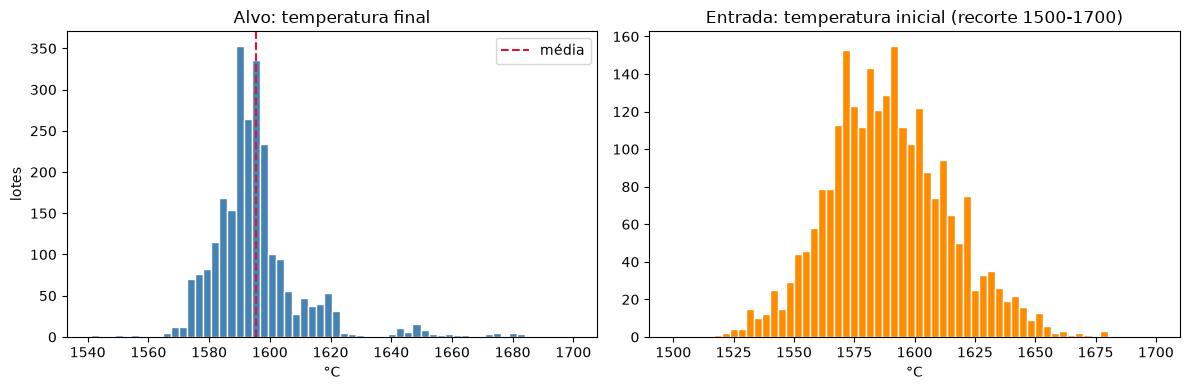

assimetria do alvo: 2.19


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(base['temp_final'], bins=60, color='steelblue', edgecolor='white')
ax[0].axvline(base['temp_final'].mean(), color='crimson', ls='--', label='média')
ax[0].set(title='Alvo: temperatura final', xlabel='°C', ylabel='lotes')
ax[0].legend()

ax[1].hist(base['temp_inicial'], bins=60, range=(1500, 1700), color='darkorange', edgecolor='white')
ax[1].set(title='Entrada: temperatura inicial (recorte 1500-1700)', xlabel='°C')

plt.tight_layout()
plt.show()

print('assimetria do alvo:', round(base['temp_final'].skew(), 2))

O recorte no segundo gráfico é para o outlier de 1.191 °C não achatar a escala.

## 3. Hipóteses de modelagem

O problema é de regressão contínua. Vou avaliar três famílias de algoritmos, mais um piso de
comparação.

### Modelo linear: LinearRegression e a variante Ridge

A relação física central é aproximadamente proporcional, já que mais energia injetada no banho produz
maior elevação de temperatura. Um modelo linear é ponto de partida legítimo, é rápido e tem a
vantagem de ser explicável para a engenharia de processo, que precisa concordar com o modelo antes de
usá-lo.

Começo com `LinearRegression`, por mínimos quadrados ordinários. Existe, porém, uma razão concreta
para esperar problema: os atributos energéticos que vou construir medem aspectos correlacionados do
mesmo esforço, porque energia total de arco, tempo de arco ligado e número de aquecimentos crescem
juntos. Sob multicolinearidade os coeficientes de mínimos quadrados ficam instáveis e podem assumir
magnitudes grandes com sinais opostos que se cancelam entre si. A previsão sobrevive a isso, mas a
leitura física não: um coeficiente indicando que mais tempo de arco resfria o aço não é apresentável
para a operação. Como a interpretabilidade é a única razão para usar modelo linear neste caso, esse
efeito anularia o motivo da escolha.

Por isso a decisão fica condicionada a uma verificação. Vou medir a correlação entre os atributos
energéticos e, se a colinearidade se confirmar, treino também `Ridge`, que penaliza a magnitude dos
coeficientes e os mantém estáveis, reportando a comparação entre as duas versões. Se desempenho e
coeficientes ficarem equivalentes, a colinearidade não estava atrapalhando e registro a verificação
como feita. Se o `Ridge` produzir coeficientes fisicamente mais coerentes, o problema existia e a
regularização o resolveu.

Um pressuposto precisa ser respeitado: `Ridge` é sensível à escala das variáveis, porque a penalidade
incide sobre a magnitude dos coeficientes e atributos em unidades diferentes seriam penalizados de
forma desigual. O escalonamento dentro do pipeline, descrito na seção 5, é obrigatório para essa
variante e não apenas conveniente. As duas versões são sensíveis a outliers, o que reforça a limpeza
descrita na seção 2.3.

### Random Forest

Algoritmo baseado em árvores que não exige escalonamento e captura interações não lineares sem que eu
precise especificá-las. Um exemplo plausível neste processo: o efeito de resfriamento da purga pode
depender da massa de liga já adicionada. Com 2.475 observações e cerca de 40 atributos, o risco de
sobreajuste é real e será controlado limitando profundidade (`max_depth`) e exigindo um mínimo de
amostras por folha (`min_samples_leaf`).

### LightGBM

Gradient boosting costuma apresentar o melhor desempenho em dados tabulares industriais. Como a
amostra é moderada, vou usar poucas folhas (`num_leaves`) e parada antecipada para conter o
sobreajuste. Se o LightGBM se mostrar instável com esse tamanho de amostra, testo CatBoost como
alternativa da mesma família.

### Piso de comparação e critério de escolha

Além das três famílias, um `DummyRegressor` pela média serve de piso: qualquer modelo que não o supere
com folga não justifica existir.

O critério de escolha não é apenas o menor erro. O modelo linear cumpre um segundo papel além de
competir por desempenho, que é o de referência interpretável contra a qual o ganho dos modelos de
árvore precisa se justificar. Se a floresta aleatória superar a regressão linear por 0,3 °C de MAE, o
ganho não paga a perda de explicabilidade no contexto industrial, e a recomendação final deve dizer
isso em vez de escolher automaticamente o menor erro.

Nenhuma das três famílias exige normalidade da variável-alvo.

## 4. Indicadores-chave e limiares

A métrica principal é o erro absoluto médio (MAE), em graus Celsius:

$$MAE = \frac{1}{n}\sum_{i=1}^{n} |T_i - \hat{T_i}|$$

Escolhi o MAE como métrica principal porque ele é lido na mesma unidade da decisão do operador. Um
MAE de 6 °C significa que a previsão erra, tipicamente, seis graus, o que o operador consegue traduzir
diretamente em confiança para dispensar ou não um ciclo de aquecimento.

O piso de comparação vem de um modelo trivial que sempre preveja a média do alvo. Para uma
distribuição aproximadamente normal, o MAE desse modelo é cerca de 0,8 vez o desvio padrão, o que
neste caso dá aproximadamente 0,8 × 16,0 = 12,8 °C. Esse é o erro a bater.

A meta de aceitação é MAE menor ou igual a 6,8 °C, praticamente a metade do modelo trivial. O limiar
não é arbitrário nem importado de outro projeto: sai do desvio padrão medido nestes dados na seção
2.7. A justificativa operacional é que as correções de temperatura no forno-panela acontecem em
incrementos pequenos, e um erro médio acima de 8 a 10 °C não deixaria margem de confiança suficiente
para o operador dispensar um ciclo de aquecimento, que é exatamente a decisão que o modelo pretende
apoiar.

Acompanho também o RMSE, que penaliza desvios grandes e isolados de forma mais severa que o MAE, e o
R², para medir quanta variância o modelo explica.

Não vou usar MAPE. Com o alvo em torno de 1.595 °C, um erro de 10 °C equivale a 0,63%, e qualquer
modelo, inclusive o trivial, ficaria abaixo de 1%. A métrica comprimiria todas as diferenças em uma
faixa estreita e não discriminaria nada.

## 5. Desenho experimental

### Separação entre treino e teste

Respeitando a natureza temporal da produção, a separação é feita por corte cronológico de 80% para
treino e 20% para teste, sobre a janela íntegra de 03/05 a 05/08/2019:

- Treino: cerca de 1.980 lotes, de 03/05 até meados de julho
- Teste: cerca de 495 lotes, de meados de julho até 05/08

O corte reproduz a aplicação real, que é treinar com histórico passado para prever corridas futuras.

Cabe um esclarecimento sobre o motivo, porque a razão usual não se aplica aqui. Testei deriva no alvo
e não encontrei: as médias mensais ficaram em 1.596,8, 1.595,2, 1.594,2 e 1.594,2 °C. Um split
aleatório provavelmente daria resultado parecido, e chamá-lo de vazamento seria impreciso. Vazamento
exige dependência temporal entre observações, e o que um split aleatório produziria aqui é uma
avaliação otimista e desalinhada com o uso, que é coisa diferente. Mantenho o corte cronológico
porque ele mede o que a operação vai de fato experimentar, e porque a ausência de deriva em três
meses não garante ausência de deriva no futuro.

Existe, porém, uma dependência temporal real neste processo, e ela precisa ser registrada: a memória
térmica do refratário da panela. Uma panela que acabou de processar uma corrida está mais quente e
rouba menos calor do banho seguinte. Daí duas decisões. Primeira, `key` e timestamps crus nunca entram
como atributos, porque codificariam a posição na série em vez da física. Segunda, o intervalo desde o
fim do lote anterior entra como atributo, funcionando como proxy do estado térmico da panela.

### Validação cruzada

Para ajuste de hiperparâmetros dentro do conjunto de treino, uso `TimeSeriesSplit` com 5 divisões,
que só valida em janelas posteriores às de treino e nunca embaralha a ordem.

Todo o pré-processamento fica dentro de um `Pipeline` do scikit-learn, incluindo o escalonamento. A
razão é técnica e vale explicitar: se eu escalonar antes de dividir, a média e o desvio padrão usados
na normalização terão sido calculados com informação do conjunto de teste, e isso é vazamento de
verdade, ainda que sutil. Dentro do pipeline, o escalonador é ajustado apenas na parte de treino de
cada dobra.

### Ajuste de hiperparâmetros por algoritmo

Cada família precisa de uma estratégia própria, porque os riscos são diferentes e as necessidades
dos modelos também são diferentes.

No modelo linear há um único hiperparâmetro relevante, o `alpha` do `Ridge`, que controla a força
da penalidade. Vou varrê-lo em escala logarítmica e escolher pelo erro na validação cruzada, com
`alpha` igual a zero na comparação, que reproduz a `LinearRegression` pura.

Na Random Forest o risco é o sobreajuste, já que 2.475 lotes e cerca de 40 atributos permitem que
árvores profundas decorem a amostra. Vou ajustar `max_depth`, `min_samples_leaf` e
`max_features` por busca aleatória, com número de árvores fixo em um valor alto o bastante para o
resultado estabilizar.

No LightGBM o risco é o mesmo, agravado pelo boosting corrigir o próprio erro repetidamente. Vou
ajustar `num_leaves`, `learning_rate` e `min_child_samples`, e usar parada antecipada com base na
última dobra temporal, o que define o número de árvores sem que eu precise escolhê-lo.

Balanceamento de classes não se aplica: o problema é de regressão e não existe classe minoritária
a compensar.

A ligação com o KPI é direta. O piso do modelo trivial é 12,8 °C e a meta é 6,8 °C. A validação
cruzada temporal serve para medir se essa distância está sendo vencida por sinal real e não por
sorte de partição, e o ajuste de hiperparâmetros é o que resta quando a escolha do algoritmo já foi
feita. Se nenhuma das três famílias chegar ao limiar depois do ajuste, a conclusão honesta não é
afrouxar a meta, e sim reportar que o teto do processo está acima dela e explicar por quê, apoiado
na convergência de setpoint identificada na seção 2.7.

## 6. Ações a executar

### Processamento e limpeza

| Atividade | Estimativa |
|---|---:|
| Padronizar tipos e converter os campos de data e hora das sete fontes | 2 h |
| Tratar o erro de sensor em `Reactive power` e verificar outliers de `Active power` | 2 h |
| Descartar `Bulk 8` e `Wire 5`, preencher com zero as demais colunas de granel e arame | 2 h |
| Remover tratamentos interrompidos (duração acima de 100,6 min) e abortados, e o lote com temperatura inicial de 1.191 graus | 3 h |
| Excluir os lotes a partir de 06/08, incompatíveis com a formulação do alvo | 1 h |

### Preparação dos dados

| Atividade | Estimativa |
|---|---:|
| Agregar eventos por lote: energia de arco, contagens, durações, gás, massas de granel e arame | 6 h |
| Construir alvo e temperatura inicial, ordenando por `Sampling time` | 3 h |
| Construir o intervalo desde o lote anterior, com limite inferior em zero e marcação dos 95 casos sobrepostos | 2 h |
| Montar a separação temporal 80/20 e o pipeline de escalonamento | 2 h |

### Desenvolvimento de modelos

| Atividade | Estimativa |
|---|---:|
| `DummyRegressor` pela média como piso de comparação | 1 h |
| Treinar e validar o modelo linear, Random Forest e LightGBM com validação cruzada temporal | 8 h |
| Ajustar hiperparâmetros do melhor modelo por busca aleatória | 6 h |
| Calcular importância de variáveis por permutação e analisar resíduos | 3 h |

### Comunicação de resultados

| Atividade | Estimativa |
|---|---:|
| Gráficos de exploração e de erro: distribuição do alvo, resíduo por temperatura inicial e por energia aplicada, importância de variáveis | 4 h |
| Relatório da Etapa 3 em estrutura Contexto, Ação, Resultado, com estimativa de impacto financeiro | 8 h |


## 7. Stakeholders impactados

A gerência de produção da aciaria responde por custo por tonelada e por disponibilidade da estação
de tratamento. Reduzir ciclos de reaquecimento libera tempo de panela, o que aumenta a capacidade de
processamento sem investimento em ativo.

A engenharia de processo é o cliente técnico direto. Vai avaliar se as relações que o modelo
encontra são metalurgicamente plausíveis e é quem pode converter a previsão em ajuste de
procedimento operacional. Sem a concordância dessa área o modelo não entra em uso, e foi por isso
que a interpretabilidade entrou como critério na escolha dos algoritmos na seção 3.

A controladoria e a área de gestão de energia entram porque a energia do arco elétrico é o maior
custo variável do refino secundário. São elas que precisam da estimativa de economia em reais para
aprovar ou priorizar a iniciativa, e são as interlocutoras naturais da estimativa de impacto pedida
na Etapa 3.

A manutenção é afetada porque superaquecimento acelera o desgaste do revestimento refratário e do
eletrodo de grafite. Menos energia aplicada em excesso significa intervalo maior entre trocas, o que
é custo evitado e parada de produção evitada.

A área de sustentabilidade tem interesse porque consumo elétrico se converte em emissões
reportadas. Uma redução mensurável de MWh por tonelada vira indicador de meta corporativa e não
apenas economia de custo.

A operação de turno é usuária final, mas não a tratei como stakeholder de decisão nesta etapa: ela
consumiria o resultado por meio de procedimento definido pela engenharia de processo, e não
diretamente pelo modelo.


## 8. Limitações e riscos conhecidos

Registro aqui o que já sei que vai limitar a solução, para não apresentar como surpresa na Etapa 3.

A amostra efetiva é de 2.475 lotes em 95 dias, e não os 3.214 do período completo. A mudança de
registro em 06/08 custou 26 dias de dados, cerca de 20% do período bruto.

Os dados não incluem informação sobre estado do refratário, idade ou histórico da panela, nem
composição química de entrada do aço. São fatores que influenciam a eficiência do processo, de modo
que a mesma entrada de energia pode terminar em resultados diferentes. O intervalo desde o lote
anterior é proxy apenas parcial do primeiro deles.

Não há medição direta de energia consumida em kWh, apenas potência ativa e reativa com horários de
início e fim. A energia será estimada como potência multiplicada por duração, o que assume potência
constante dentro de cada janela de aquecimento.

A massa de aço de cada corrida não é informada. O enunciado dá a capacidade aproximada de 100
toneladas da panela, mas variações reais de carga afetam a inércia térmica e ficarão como ruído
não observado.

Para valorar o impacto financeiro, três valores externos ao dataset precisam ser assumidos. A
capacidade de 100 toneladas por panela vem do enunciado do projeto. O consumo de referência de 25 a
30 kWh por tonelada vem de valores publicados por fabricantes de forno-panela. O preço da energia
vem da ABRACEEL, que publicou R$ 147/MWh no mercado livre e R$ 310/MWh no mercado cativo para 2024.
O impacto será apresentado como faixa, nunca como valor único, e com os três valores declarados ao
lado do resultado.

Por último, um risco operacional que vale destacar porque foi encontrado nos próprios dados: o
modelo depende de um registro de temperatura que a planta comprovadamente parou de gerar em
06/08/2019, sem que isso aparecesse em nenhuma verificação agregada. Antes de qualquer implantação
é necessário monitoramento de integridade dessa fonte, caso contrário o modelo perde a entrada em
silêncio e continua produzindo previsões.
